In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/raw/application_train.csv")

In [3]:
df.shape

(307511, 122)

In [4]:
df.columns.tolist()

['SK_ID_CURR',
 'TARGET',
 'NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'ORGANIZATION_TYPE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_A

In [5]:
def safe_divide(numerator, denominator):
    return numerator / (denominator + 1e-6)

In [6]:
safe_divide(100, 0)

100000000.0

In [7]:
df["debt_to_income_ratio"] = safe_divide(
    df["AMT_CREDIT"],
    df["AMT_INCOME_TOTAL"]
)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21124\1804030395.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["debt_to_income_ratio"] = safe_divide(


In [8]:
df["debt_to_income_ratio"].head()

0    2.007889
1    4.790750
2    2.000000
3    2.316167
4    4.222222
Name: debt_to_income_ratio, dtype: float64

In [9]:
df["loan_burden_ratio"] = safe_divide(
    df["AMT_ANNUITY"],
    df["AMT_INCOME_TOTAL"]
)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21124\202471611.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["loan_burden_ratio"] = safe_divide(


In [10]:
df["loan_burden_ratio"].head()

0    0.121978
1    0.132217
2    0.100000
3    0.219900
4    0.179963
Name: loan_burden_ratio, dtype: float64

In [11]:
df["credit_utilization_proxy"] = safe_divide(
    df["AMT_CREDIT"],
    df["AMT_GOODS_PRICE"]
)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21124\1952891743.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["credit_utilization_proxy"] = safe_divide(


In [12]:
df["credit_utilization_proxy"].head()

0    1.158397
1    1.145199
2    1.000000
3    1.052803
4    1.000000
Name: credit_utilization_proxy, dtype: float64

In [13]:
df["age_years"] = abs(df["DAYS_BIRTH"]) / 365

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21124\4238933765.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["age_years"] = abs(df["DAYS_BIRTH"]) / 365


In [14]:
df["age_years"].head()

0    25.920548
1    45.931507
2    52.180822
3    52.068493
4    54.608219
Name: age_years, dtype: float64

In [15]:
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(
    365243,
    np.nan
)

In [16]:
df["DAYS_EMPLOYED"].describe()

count    252137.000000
mean      -2384.169325
std        2338.360162
min      -17912.000000
25%       -3175.000000
50%       -1648.000000
75%        -767.000000
max           0.000000
Name: DAYS_EMPLOYED, dtype: float64

In [17]:
df["employment_years"] = abs(
    df["DAYS_EMPLOYED"]
) / 365

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21124\26338764.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["employment_years"] = abs(


In [18]:
df["employment_years"].head()

0    1.745205
1    3.254795
2    0.616438
3    8.326027
4    8.323288
Name: employment_years, dtype: float64

In [19]:
df["income_stability_score"] = safe_divide(
    df["AMT_INCOME_TOTAL"],
    df["employment_years"] + 1
)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21124\2392517456.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["income_stability_score"] = safe_divide(


In [20]:
df["income_stability_score"].head()

0    73764.943189
1    63457.808653
2    41758.448743
3    14475.615369
4    13031.882234
Name: income_stability_score, dtype: float64

In [21]:
new_features = [
    "debt_to_income_ratio",
    "loan_burden_ratio",
    "credit_utilization_proxy",
    "age_years",
    "employment_years",
    "income_stability_score"
]

df[new_features].head()

,debt_to_income_ratio,loan_burden_ratio,credit_utilization_proxy,age_years,employment_years,income_stability_score
0,2.007889,0.121978,1.158397,25.920548,1.745205,73764.943189
1,4.790750,0.132217,1.145199,45.931507,3.254795,63457.808653
2,2.000000,0.100000,1.000000,52.180822,0.616438,41758.448743
3,2.316167,0.219900,1.052803,52.068493,8.326027,14475.615369
4,4.222222,0.179963,1.000000,54.608219,8.323288,13031.882234


In [22]:
df[new_features].isnull().sum()

debt_to_income_ratio            0
loan_burden_ratio              12
credit_utilization_proxy      278
age_years                       0
employment_years            55374
income_stability_score      55374
dtype: int64

In [23]:
# Debt-to-income ratio
df["debt_to_income_ratio"] = safe_divide(
    df["AMT_CREDIT"],
    df["AMT_INCOME_TOTAL"]
)

# Loan burden ratio
df["loan_burden_ratio"] = safe_divide(
    df["AMT_ANNUITY"],
    df["AMT_INCOME_TOTAL"]
)

# Credit utilization proxy
df["credit_utilization_proxy"] = safe_divide(
    df["AMT_CREDIT"],
    df["AMT_GOODS_PRICE"]
)

# Age in years
df["age_years"] = abs(df["DAYS_BIRTH"]) / 365

# Handle missing employment values
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(
    365243,
    np.nan
)

# Employment years
df["employment_years"] = abs(
    df["DAYS_EMPLOYED"]
) / 365

# Income stability score
df["income_stability_score"] = safe_divide(
    df["AMT_INCOME_TOTAL"],
    df["employment_years"] + 1
)

# Family size
df["family_size"] = df["CNT_CHILDREN"] + 1

# Income per family member
df["income_per_family_member"] = safe_divide(
    df["AMT_INCOME_TOTAL"],
    df["family_size"]
)

# Credit inquiry ratio
df["credit_inquiry_ratio"] = safe_divide(
    df["AMT_REQ_CREDIT_BUREAU_YEAR"],
    df["age_years"]
)

# External score statistics
df["ext_score_mean"] = df[
    ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
].mean(axis=1)

df["ext_score_std"] = df[
    ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
].std(axis=1)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21124\689523471.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["family_size"] = df["CNT_CHILDREN"] + 1
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21124\689523471.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["income_per_family_member"] = safe_divide(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21124\689523471.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consi

In [24]:
new_features = [
    "debt_to_income_ratio",
    "loan_burden_ratio",
    "credit_utilization_proxy",
    "age_years",
    "employment_years",
    "income_stability_score",
    "family_size",
    "income_per_family_member",
    "credit_inquiry_ratio",
    "ext_score_mean",
    "ext_score_std"
]

df[new_features].head()

,debt_to_income_ratio,loan_burden_ratio,credit_utilization_proxy,age_years,employment_years,income_stability_score,family_size,income_per_family_member,credit_inquiry_ratio,ext_score_mean,ext_score_std
0,2.007889,0.121978,1.158397,25.920548,1.745205,73764.943189,1,202499.7975,0.038579,0.161787,0.092026
1,4.790750,0.132217,1.145199,45.931507,3.254795,63457.808653,1,269999.7300,0.000000,0.466757,0.219895
2,2.000000,0.100000,1.000000,52.180822,0.616438,41758.448743,1,67499.9325,0.000000,0.642739,0.122792
3,2.316167,0.219900,1.052803,52.068493,8.326027,14475.615369,1,134999.8650,NaN,0.650442,NaN
4,4.222222,0.179963,1.000000,54.608219,8.323288,13031.882234,1,121499.8785,0.000000,0.322738,NaN


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

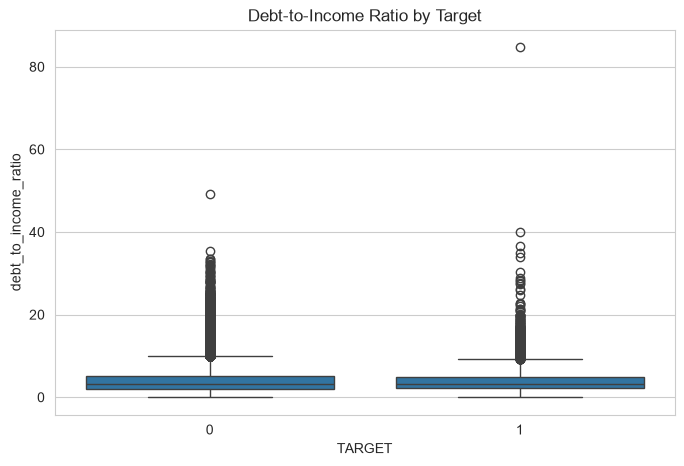

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="TARGET",
    y="debt_to_income_ratio",
    data=df
)

plt.title("Debt-to-Income Ratio by Target")

plt.show()

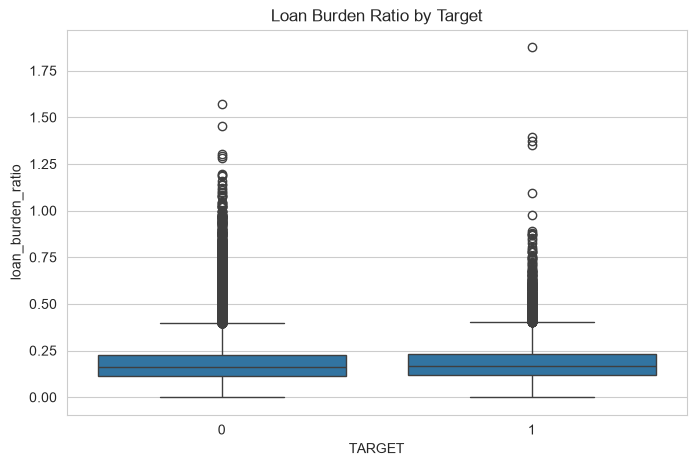

In [27]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="TARGET",
    y="loan_burden_ratio",
    data=df
)

plt.title("Loan Burden Ratio by Target")

plt.show()

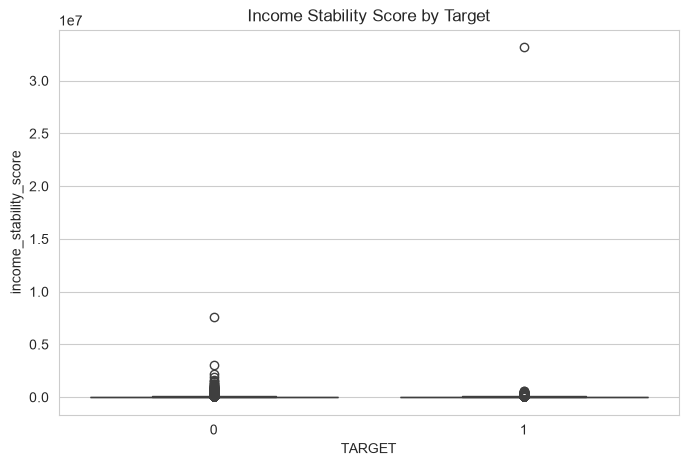

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="TARGET",
    y="income_stability_score",
    data=df
)

plt.title("Income Stability Score by Target")

plt.show()

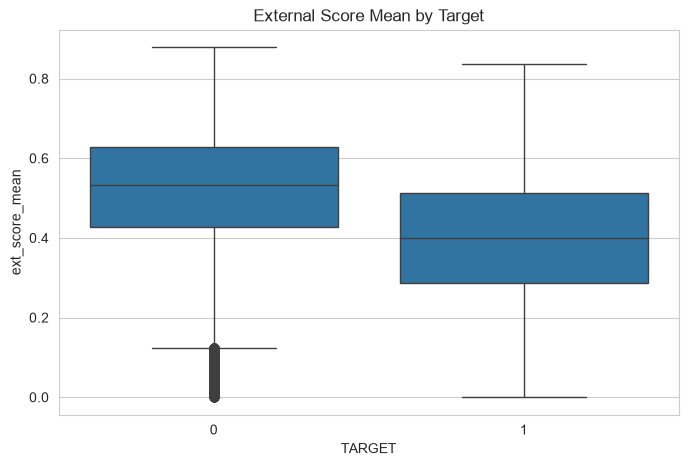

In [29]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="TARGET",
    y="ext_score_mean",
    data=df
)

plt.title("External Score Mean by Target")

plt.show()

In [30]:
engineered_features = [
    "debt_to_income_ratio",
    "loan_burden_ratio",
    "credit_utilization_proxy",
    "income_stability_score",
    "income_per_family_member",
    "credit_inquiry_ratio",
    "ext_score_mean"
]

In [31]:
df[engineered_features + ["TARGET"]].corr()["TARGET"]

debt_to_income_ratio       -0.007727
loan_burden_ratio           0.014265
credit_utilization_proxy    0.069427
income_stability_score      0.020855
income_per_family_member   -0.012529
credit_inquiry_ratio        0.040201
ext_score_mean             -0.222052
TARGET                      1.000000
Name: TARGET, dtype: float64

In [32]:
df.to_csv(
    "../data/processed/application_train_engineered.csv",
    index=False
)